#### Conception du Modèle CNN

**Définir l’architecture CNN (Conv2D + MaxPooling + Dropout + Dense) avec des paramètres optimaux:**

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, SpatialDropout2D

model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(SpatialDropout2D(0.25))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(SpatialDropout2D(0.25))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(SpatialDropout2D(0.25))

model.add(Flatten())

model.add(Dense(128, activation='sigmoid'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))
model.summary()


c:\Users\oussa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 111, 111, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 54, 54, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 26, 26, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Choisir les meilleures fonctions d’activation pour les couches cachées et la couche de sortie:**


**Compiler le modèle (ex. : Optimiseur Adam, fonction de perte categorical_crossentropy):**

In [2]:

from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


In [10]:
import numpy as np

data = np.load('../data/processed/dataset_prepared.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

In [ ]:
import time
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint




early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



checkpoint = ModelCheckpoint(
    filepath="../models/best_model.keras",  
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint,early_stop]
)

end_time = time.time()
training_duration = end_time - start_time
print(f"Training duration: {training_duration/60:.2f} seconds")

Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.4655 - loss: 1.2051
Epoch 1: val_accuracy improved from None to 0.71406, saving model to ../models/best_model.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 0.5816 - loss: 0.9556 - val_accuracy: 0.7141 - val_loss: 0.6464
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.7218 - loss: 0.6674
Epoch 2: val_accuracy improved from 0.71406 to 0.78047, saving model to ../models/best_model.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 48s 300ms/step - accuracy: 0.7277 - loss: 0.6333 - val_accuracy: 0.7805 - val_loss: 0.5338
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7763 - loss: 0.5277
Epoch 3: val_accuracy improved from 0.78047 to 0.80859, saving model to ../models/best_model.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.7758 - loss: 0.5209 - val_accuracy: 0.8086 - val_loss: 0.4707
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.8218 - loss: 0

**Évaluer les performances sur l’ensemble de test**


In [ ]:
from tensorflow.keras.models import load_model
import joblib
model = load_model("../models/best_model.keras")

labelencoder = joblib.load("label_encoder.pkl")
print("Encodeur chargé !")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Encodeur chargé !
Test Accuracy: 86.19%
Test Loss: 0.3130


**Visualiser les courbes d’apprentissage**

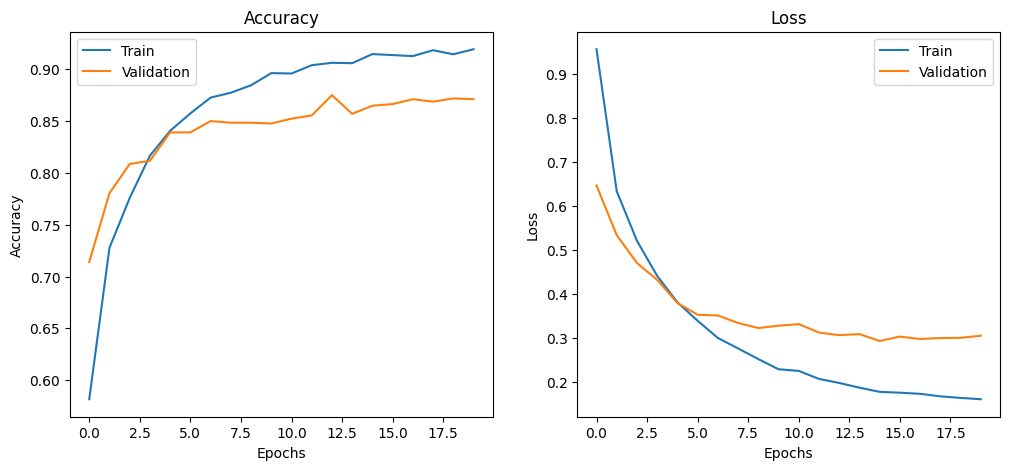

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


**Générer une matrice de confusion + rapport de classification**

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step


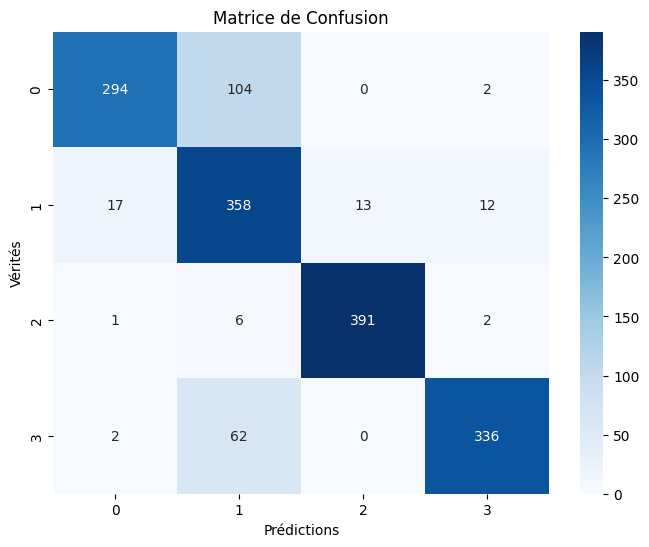

              precision    recall  f1-score   support

           0       0.94      0.73      0.82       400
           1       0.68      0.90      0.77       400
           2       0.97      0.98      0.97       400
           3       0.95      0.84      0.89       400

    accuracy                           0.86      1600
   macro avg       0.88      0.86      0.86      1600
weighted avg       0.88      0.86      0.86      1600



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de Confusion")
plt.show()

print(classification_report(y_true, y_pred_classes))


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step


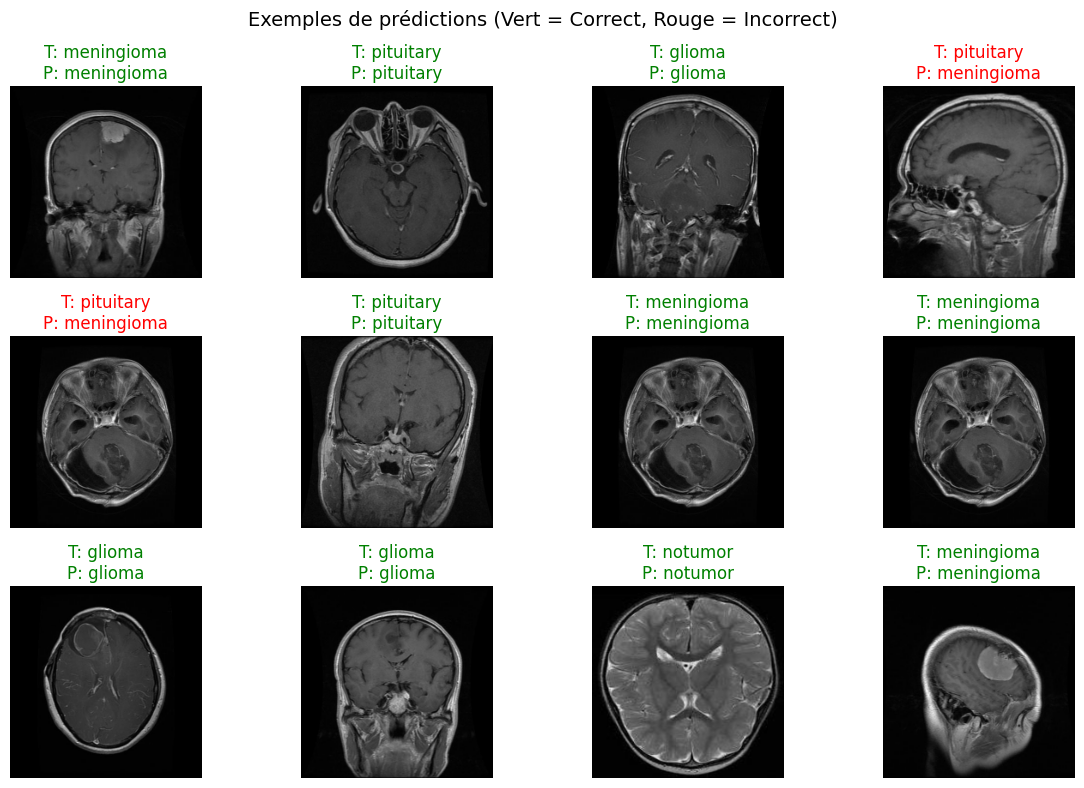

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

true_labels = labelencoder.inverse_transform(y_true)
pred_labels = labelencoder.inverse_transform(y_pred_classes)

indices = random.sample(range(len(X_test)), 12)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])
    true_label = true_labels[idx]
    pred_label = pred_labels[idx]
    color = "green" if true_label == pred_label else "red"
    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis("off")

plt.suptitle("Exemples de prédictions (Vert = Correct, Rouge = Incorrect)", fontsize=14)
plt.tight_layout()
plt.show()


True
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


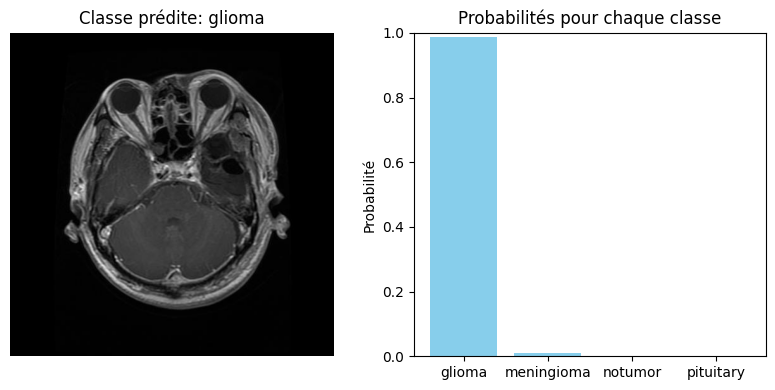

{np.str_('glioma'): np.float32(0.9859629), np.str_('meningioma'): np.float32(0.011618247), np.str_('notumor'): np.float32(1.9283194e-05), np.str_('pituitary'): np.float32(0.0023995233)}


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

model = load_model("../models/best_model.keras")  

labelencoder = joblib.load("../models/labelencoder.pkl")
class_names = labelencoder.classes_

def predict_image_verbose(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_resized = img_resized.astype('float32') / 255.0
    img_resized = np.expand_dims(img_resized, axis=0) 
    # Prédiction
    pred_probs = model.predict(img_resized)
    pred_class_idx = np.argmax(pred_probs, axis=1)[0]
    pred_class_name = labelencoder.inverse_transform([pred_class_idx])[0]

    
    plt.figure(figsize=(8, 4))

    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Classe prédite: {pred_class_name}")

  
    plt.subplot(1, 2, 2)
    plt.bar(class_names, pred_probs[0], color='skyblue')
    plt.ylabel("Probabilité")
    plt.ylim(0, 1)
    plt.title("Probabilités pour chaque classe")

    plt.tight_layout()
    plt.show()

    
    return dict(zip(class_names, pred_probs[0]))
import os
print(os.path.exists("../data/raw/Data/glioma/Te-gl_0010.jpg"))

probs = predict_image_verbose("../data/raw/Data/glioma/Te-gl_0011.jpg")
print(probs)
